In [1]:
# Basic python libraries
import os
import time
import joblib
import pandas as pd
import numpy as np

# Visualizarition libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn and other ml functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, recall_score, precision_score, accuracy_score, f1_score, roc_auc_score
)

In [46]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab import userdata

    train_path = userdata.get('mitbih_train')
    df_train = pd.read_csv(train_path, header=None)

    test_path = userdata.get('mitbih_test')
    df_test = pd.read_csv(test_path, header=None)
except:
    train_path = "../../proyecto/data/mitbih_train.csv"
    df_train = pd.read_csv(train_path, header=None)

    test_path = "../../proyecto/data/mitbih_test.csv"
    df_test = pd.read_csv(test_path, header=None)

# Set the train and test arrays
X_train,y_train = df_train.iloc[:,:-1], df_train.iloc[:,-1]
X_test, y_test = df_test.iloc[:,:-1], df_test.iloc[:,-1]

# Evaluación de modelos benchmark

En este capítulo se evualúan diferentes modelos de machine learning y deep learning que nos permitan identificar arritmias cardiacas, según el problema propuesto. Para esto se presentan tres secciones, una con el balanceo de clases, otra con le benchmark de modelos y finalmente una comparación con los resultados obtenidos para todos los modelos.


## 1. Balanceo de clases


SMOTE (Synthetic Minority Over-sampling Technique), ADASYN (Adaptive Synthetic Sampling), class_weight='balanced' de Scikit-learn.

## 2. Benchmark de modelos

En esta capítulo de presenta el benchmark de los siguientes modelos:

- **KNN**
- **Regresión Logística** (Regularización L1/L2)
- **Decision Tree**
- **Random Forest**
- **XGBoost (Lime)**
- **SVM**
- **MLP**
- **LSTM**
- **CNN**
- **Autoencoders**

Además, se utilizarán los siguientes algotirmos de computo para comprar sus tiempore de convergencia.

- **KNN** → KD-Trees, Ball Trees, FAISS.
- **XGBoost** → tree_method='hist' y early_stopping_rounds.
- **SVM** → SGD SVM (SGDClassifier)
- LinearSVC en lugar de SVC(kernel='linear')

Finalmente, como método de evaluación se utilizará el **Recall Macro**, como un medida de confiabilidad para la presentación de resultados. Además, de Matrices de confusión, curvas ROC y reporte de clasificación.

### Configuración de la ejecución

In [ ]:
scorer = "recall_macro" # Definimos el recall como métrica para cross validation en grid search
n_jobs = -2 # Usamos todos menos uno de los cores de la CPU
refit = True # Reentrenamos el modelo con el mejor conjunto de hiperparámetros
verbose = 1 # Mostramos el progreso de la búsqueda de hiperparámetros
cv = 5 # Usamos 5 folds para la validación cruzada
random_state=42 # Semilla para la aleatoriedad

In [ ]:
def evaluate_and_save_model(grid_search_fitted, model_name, X_test, y_test, training_time):
    """
    Evaluates the best estimator from a grid search fitted model and saves evaluation results.

    Parameters:
    - grid_search_fitted (GridSearchCV): Fitted GridSearchCV object containing the best estimator.
    - model_name (str): Name of the model for saving results.
    - X_test (array-like of shape (n_samples, n_features)): Test data features.
    - y_test (array-like of shape (n_samples,)): True labels for test data.
    - training_time (float): Time taken to train the model.

    Returns:
    - None: Saves evaluation results and best estimator model to files.

    Notes:
    - Results are saved as pickle files: {model_name}_results.pkl and best_{model_name}_model.pkl
    - Evaluation metrics include precision, recall, accuracy, F1 score, confusion matrix, ROC AUC score, and classification report.
    """

    # Obtain best estimator from grid search
    best_estimator = grid_search_fitted.best_estimator_

    # Predict with test data
    y_pred = best_estimator.predict(X_test)


    # Intentar obtener probabilidades si el modelo lo permite
    if hasattr(best_estimator, "predict_proba"):
        y_pred_proba = best_estimator.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    elif hasattr(best_estimator, "decision_function"):  # Para modelos como LinearSVC
        y_pred_proba = best_estimator.decision_function(X_test)
        auc = np.nan  # No se puede calcular el AUC directamente en clasificación multiclase sin probabilidades
    else:
        y_pred_proba = None
        auc = np.nan

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    # auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr') if hasattr(best_estimator, 'predict_proba') else np.nan
    report = classification_report(y_test, y_pred)

    # Save evaluation results
    results = {
        'precision_test': precision,
        'recall_test': recall,
        'accuracy_test': accuracy,
        'f1_score_test': f1,
        'confusion_matrix': cm,
        'y_pred_prob': y_pred_proba,
        'auc_test': auc,
        'classification_report': report,
        'cpu_time': training_time,
        'best_params': grid_search_fitted.best_params_,
        'best_recall_cv': grid_search_fitted.best_score_,
        'cv_results': grid_search_fitted.cv_results_
    }

    # Save results and best model
    joblib.dump(results, f"results/{model_name}_results.pkl")
    joblib.dump(best_estimator, f"models/best_{model_name}_model.pkl")
    print(f"Modelo y resultados guardados exitosamente en 'models/best_{model_name}_model.pkl' y 'results/{model_name}_results.pkl'.")

### KNN

In [ ]:
# Libraries for knn
from sklearn.neighbors import KNeighborsClassifier

#### Definir los hiperparámetos

In [ ]:
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7],
    'algorithm': ['ball_tree', 'kd_tree', 'auto']
}

#### Grid search para entrenar el mejor estimador

In [ ]:
knn = KNeighborsClassifier()
start_time = time.time()
knn_grid_search = GridSearchCV(knn, knn_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
knn_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 12 candidates, totalling 60 fits


#### Guardamos los resultados

In [ ]:
model_name = "knn" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(knn_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_knn_model.pkl' y 'results/knn_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
knn_results = joblib.load("results/knn_results.pkl")

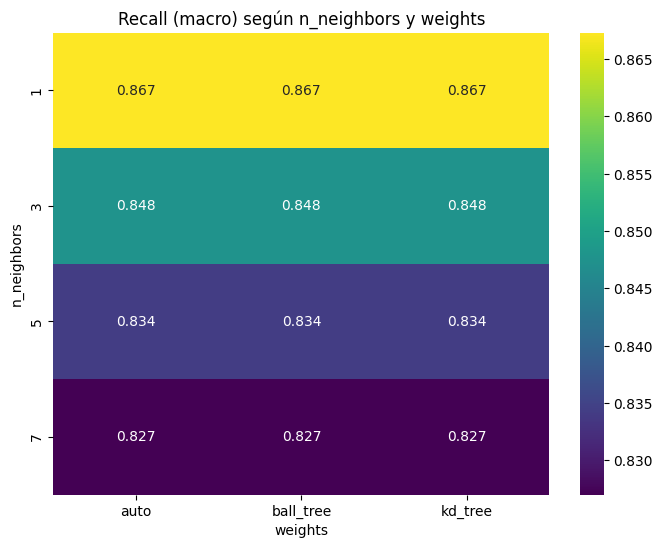

In [ ]:
cv_results_df = pd.DataFrame(knn_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_n_neighbors',
                                  columns='param_algorithm',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

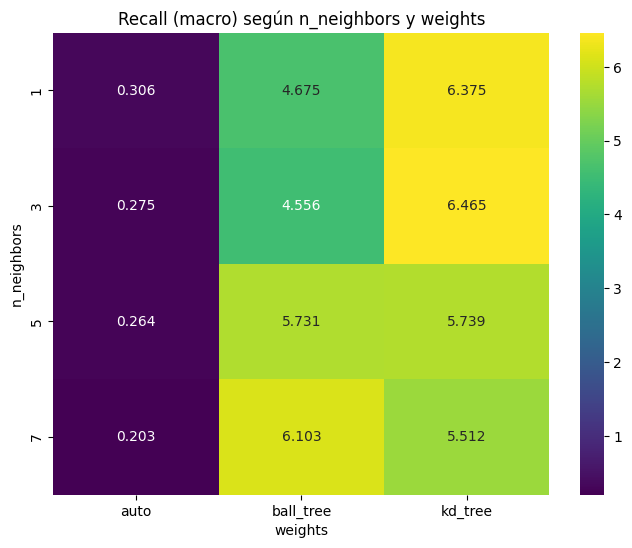

In [ ]:
pivot = cv_results_df.pivot_table(index='param_n_neighbors',
                                  columns='param_algorithm',
                                  values='mean_fit_time')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("fit time (segs) Por algoritmo")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

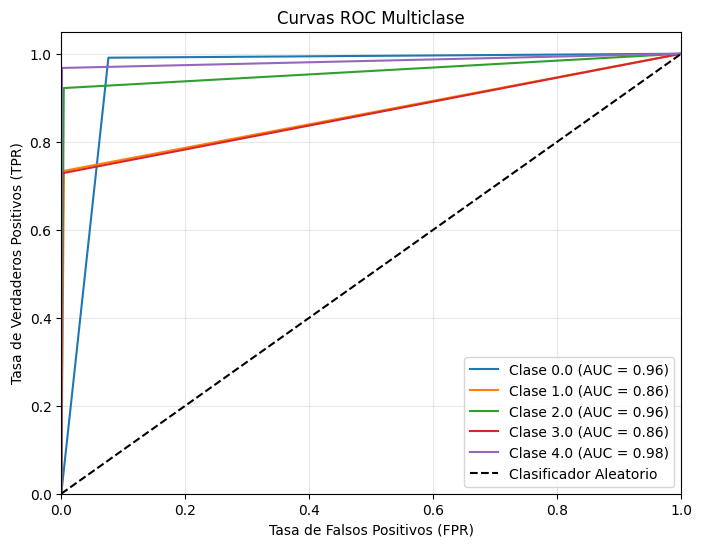

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = knn_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

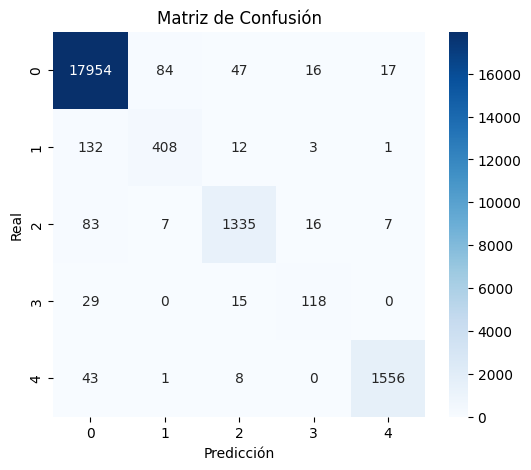

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(knn_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", knn_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     18118
         1.0       0.82      0.73      0.77       556
         2.0       0.94      0.92      0.93      1448
         3.0       0.77      0.73      0.75       162
         4.0       0.98      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.87      0.88     21892
weighted avg       0.98      0.98      0.98     21892



### Decision Tree

In [ ]:
# libraries for decision trees
from sklearn.tree import DecisionTreeClassifier

#### Definir los hiperparámetos

In [ ]:
# Set the hyperparameters

tree_param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy'],
}


#### Grid search para entrenar el mejor estimador

In [ ]:
tree = DecisionTreeClassifier(random_state=random_state)
start_time = time.time()
tree_grid_search = GridSearchCV(tree, tree_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
tree_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 12 candidates, totalling 60 fits


#### Guardamos los resultados

In [ ]:
model_name = "tree" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(tree_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_tree_model.pkl' y 'results/tree_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
tree_results = joblib.load("results/tree_results.pkl")

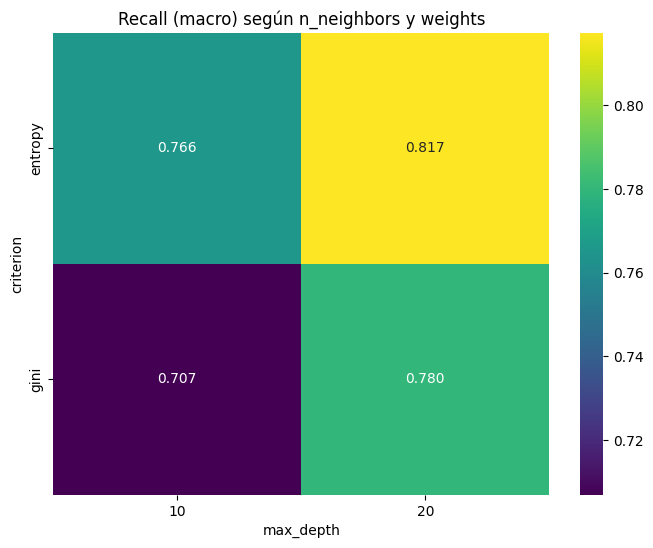

In [ ]:
cv_results_df = pd.DataFrame(tree_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_criterion',
                                  columns='param_max_depth',
                                  values='mean_test_score')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("max_depth")
plt.ylabel("criterion")
plt.show()

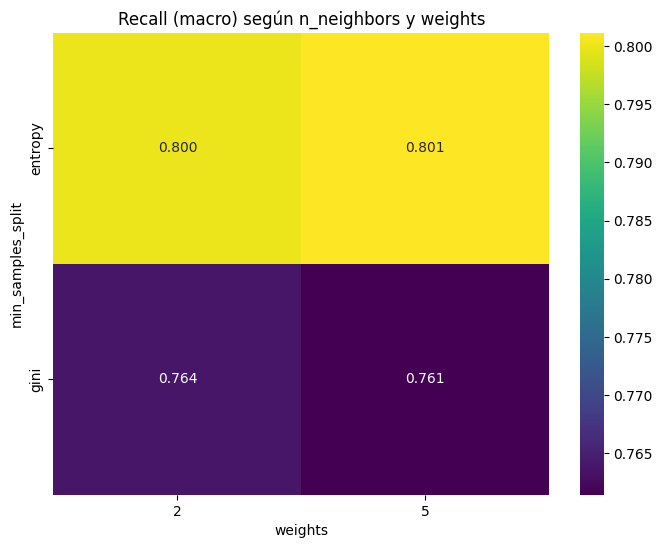

In [ ]:
pivot = cv_results_df.pivot_table(index='param_criterion',
                                  columns='param_min_samples_split',
                                  values='mean_test_score')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("min_samples_split")
plt.show()

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

tree_estimador = joblib.load('models/best_tree_model.pkl')

export_graphviz(tree_estimador,
                out_file="results/tree.dot",
                impurity=False,
                filled=True)

with open("results/tree.dot") as f:
    dot_graph = f.read()
    graph = graphviz.Source(dot_graph)

graphviz.Source(dot_graph)

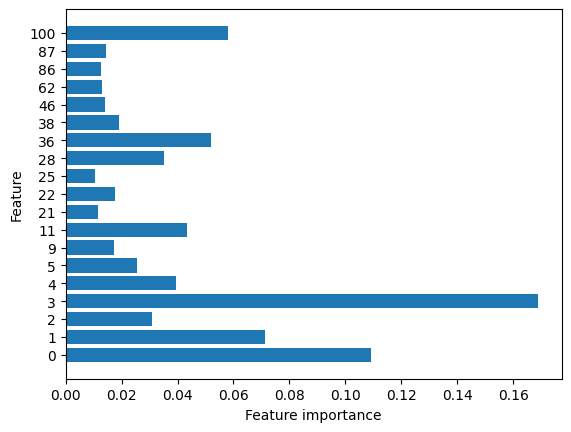

In [ ]:
importances = tree_estimador.feature_importances_
mask = importances > 0.01
filtered_importances = importances[mask]
filtered_features = X_train.columns[mask].astype(str)

plt.barh(np.arange(len(filtered_importances)), filtered_importances, align='center')
plt.yticks(np.arange(len(filtered_importances)), filtered_features)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

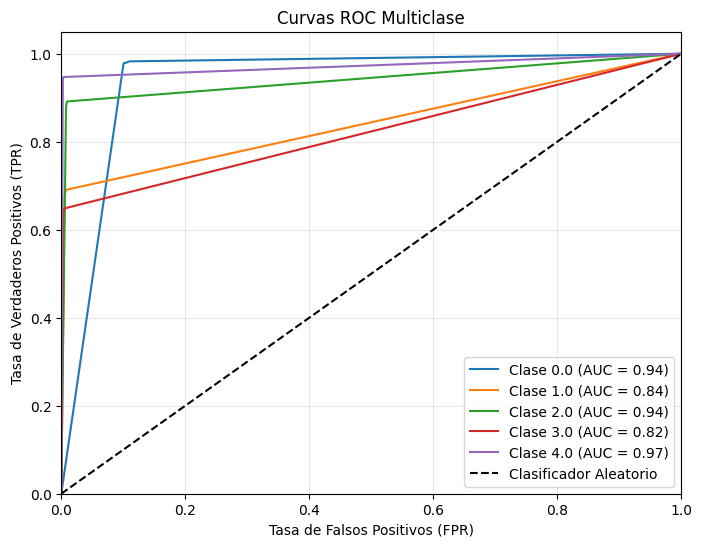

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = tree_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

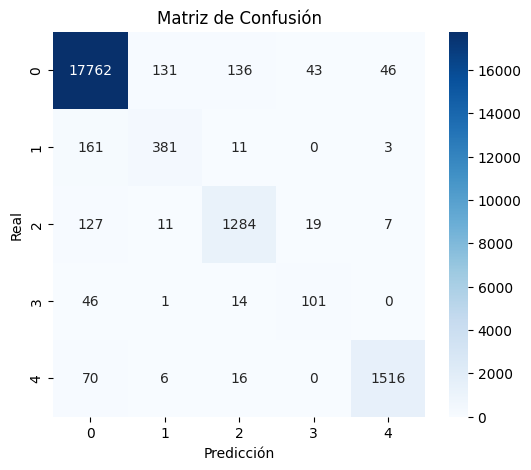

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(tree_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", tree_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     18118
         1.0       0.72      0.69      0.70       556
         2.0       0.88      0.89      0.88      1448
         3.0       0.62      0.62      0.62       162
         4.0       0.96      0.94      0.95      1608

    accuracy                           0.96     21892
   macro avg       0.83      0.82      0.83     21892
weighted avg       0.96      0.96      0.96     21892



In [ ]:
pd.DataFrame(tree_results["cv_results"]).sort_values(by="rank_test_score", ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,28.281401,0.350393,0.025302,0.001600,entropy,None,5,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.834703,0.829143,0.806245,0.809005,0.816709,0.819161,0.011110,1
11,24.388292,0.742805,0.018999,0.001673,entropy,20,5,"{'criterion': 'entropy', 'max_depth': 20, 'min...",0.833463,0.822398,0.809584,0.812500,0.815908,0.818770,0.008496,2
6,29.123919,0.325252,0.024600,0.001623,entropy,None,2,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.828253,0.826122,0.804967,0.814492,0.813230,0.817413,0.008652,3
10,26.653801,0.752611,0.022399,0.002577,entropy,20,2,"{'criterion': 'entropy', 'max_depth': 20, 'min...",0.826918,0.822659,0.805389,0.810408,0.815119,0.816098,0.007850,4
0,44.518721,1.361803,0.037007,0.003486,gini,None,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.809401,0.800555,0.788808,0.806297,0.810785,0.803169,0.007996,5
1,44.392492,1.377895,0.034506,0.003776,gini,None,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.813110,0.795805,0.790335,0.806895,0.790083,0.799246,0.009229,6
4,23.486303,0.137720,0.030402,0.001626,gini,20,2,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.783653,0.788089,0.769154,0.789471,0.777107,0.781495,0.007527,7
5,23.353283,0.050061,0.026800,0.001327,gini,20,5,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.780668,0.782953,0.768290,0.786696,0.770166,0.777754,0.007247,8
8,21.657659,0.171903,0.024302,0.001884,entropy,10,2,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.738223,0.781583,0.747689,0.797494,0.767910,0.766580,0.021650,9
9,21.610049,0.156902,0.023200,0.000748,entropy,10,5,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.738347,0.783031,0.746274,0.793917,0.765756,0.765465,0.021080,10


### Logistic Regresión


In [ ]:
from sklearn.linear_model import LogisticRegression

#### Definir los hiperparámetos

In [ ]:
logreg_param_grid = {
    'penalty': ['l1', 'l2', None],
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga']
}

#### Grid search para entrenar el mejor estimador

In [ ]:
logreg_clf = LogisticRegression(random_state=random_state, max_iter=1000, multi_class='auto')
start_time = time.time()
logreg_grid_search = GridSearchCV(
    logreg_clf,
    param_grid=logreg_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
logreg_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

#### Guardamos los resultados

In [ ]:
model_name = "reglog" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(logreg_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_reglog_model.pkl' y 'results/reglog_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
logreg_results = joblib.load("results/reglog_results.pkl")
cv_results_df = pd.DataFrame(logreg_results['cv_results'])

In [ ]:
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_penalty', 'param_solver', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

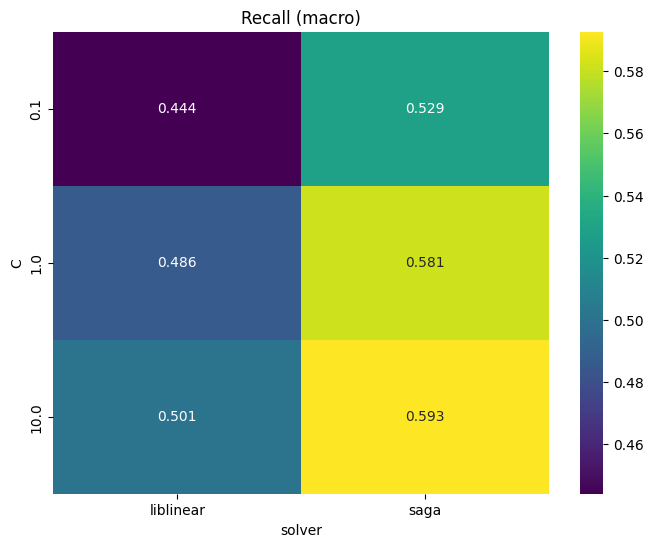

In [ ]:
pivot = cv_results_df.pivot_table(index='param_C',
                                  columns='param_solver',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("solver")
plt.ylabel("C")
plt.show()

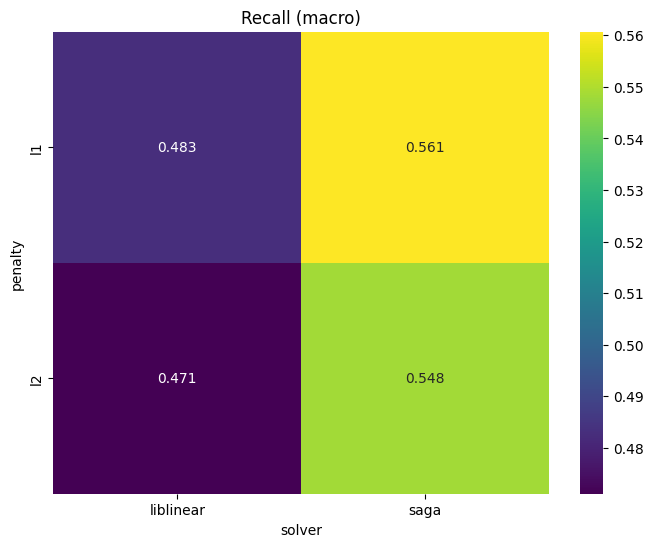

In [ ]:
pivot = cv_results_df.pivot_table(index='param_penalty',
                                  columns='param_solver',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("solver")
plt.ylabel("penalty")
plt.show()

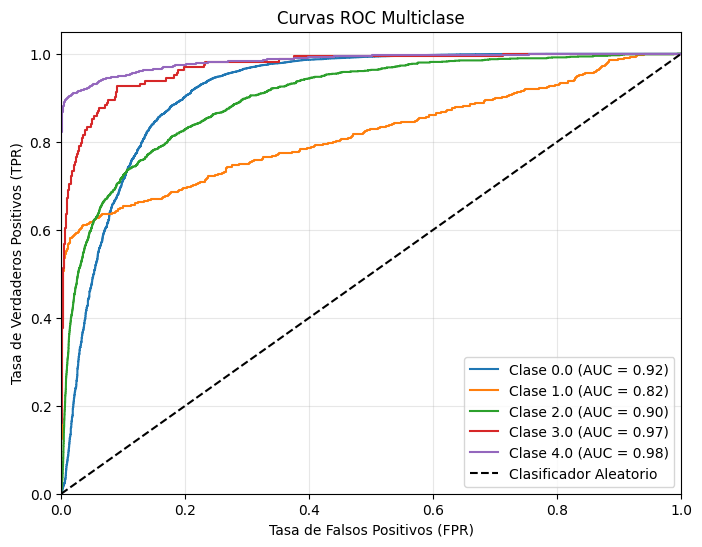

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = logreg_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

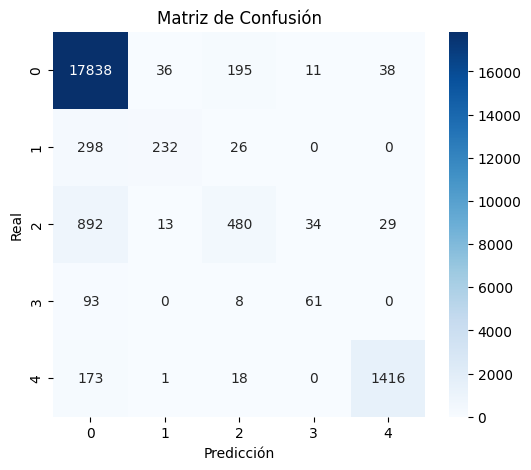

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(logreg_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", logreg_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     18118
         1.0       0.82      0.42      0.55       556
         2.0       0.66      0.33      0.44      1448
         3.0       0.58      0.38      0.46       162
         4.0       0.95      0.88      0.92      1608

    accuracy                           0.91     21892
   macro avg       0.79      0.60      0.66     21892
weighted avg       0.90      0.91      0.90     21892



### Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier

#### Definir los hiperparámetos

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
rf = RandomForestClassifier(random_state=42)
start_time = time.time()
rf_grid_search = GridSearchCV(rf, rf_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
rf_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 27 candidates, totalling 135 fits


#### Guardamos los resultados

In [ ]:
model_name = "rf" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(rf_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_rf_model.pkl' y 'results/rf_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
rf_results = joblib.load("results/rf_results.pkl")
cv_results_df = pd.DataFrame(rf_results['cv_results'])

In [ ]:
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_max_depth', 'param_min_samples_leaf', 'param_n_estimators',
       'params', 'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

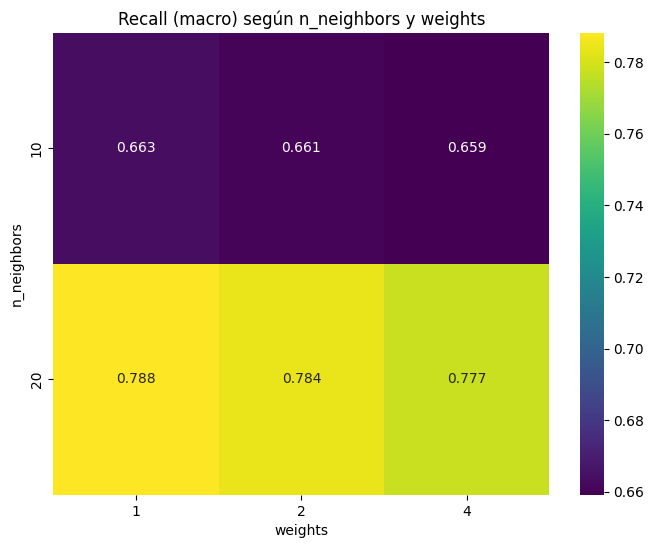

In [ ]:
pivot = cv_results_df.pivot_table(index='param_max_depth',
                                  columns='param_min_samples_leaf',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

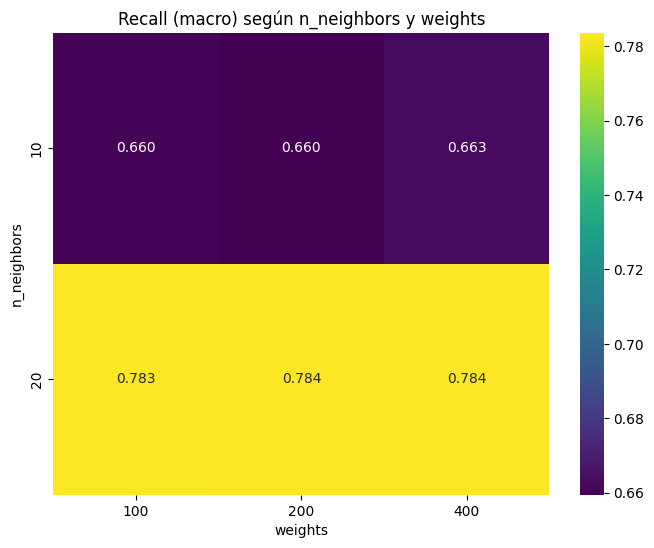

In [ ]:
pivot = cv_results_df.pivot_table(index='param_max_depth',
                                  columns='param_n_estimators',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

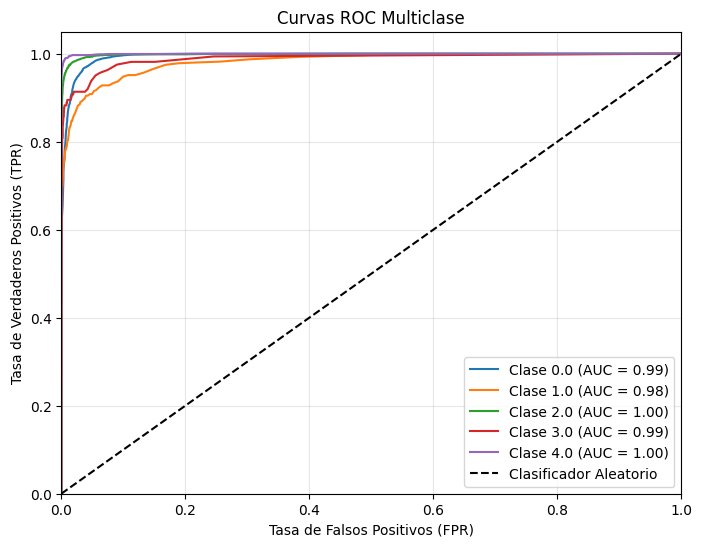

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = rf_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

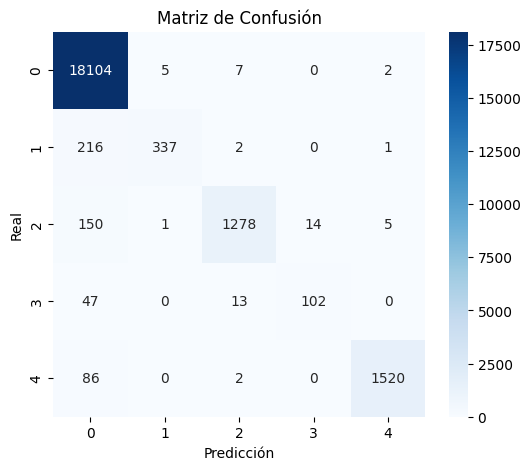

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(rf_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", rf_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.99     18118
         1.0       0.98      0.61      0.75       556
         2.0       0.98      0.88      0.93      1448
         3.0       0.88      0.63      0.73       162
         4.0       0.99      0.95      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.96      0.81      0.87     21892
weighted avg       0.97      0.97      0.97     21892



### XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
xgb_param_grid = {
    'tree_method': ['hist', 'approx'],
    'learning_rate': [0.01, 0.1, 0.2],
    #'early_stopping_rounds': [10, 20],
    #'max_depth': [3, 6],
    'n_estimators': [100,200,400]
}

#### Grid search para entrenar el mejor estimador

In [ ]:
xgb_model = xgb.XGBClassifier(device='cuda:0', verbosity=2)
start_time = time.time()
xgb_grid_search = GridSearchCV(
    xgb_model,
    param_grid=xgb_param_grid,
    scoring=scorer,
    cv=cv,
    verbose=verbose,
    n_jobs=n_jobs,
    refit=refit
)
xgb_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[05:41:57] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (87554, 187, 16372598).
[05:41:57] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.


#### Guardamos los resultados

In [ ]:
model_name = "xgb" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(xgb_grid_search, model_name, X_test, y_test, training_time)

c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\xgboost\core.py:729: UserWarning: [05:42:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Modelo y resultados guardados exitosamente en 'models/best_xgb_model.pkl' y 'results/xgb_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
xgb_results = joblib.load("results/xgb_results.pkl")
cv_results_df = pd.DataFrame(xgb_results['cv_results'])

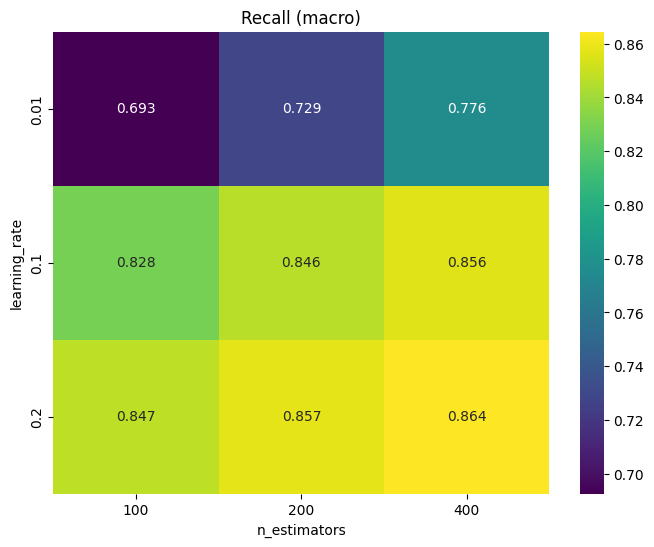

In [ ]:

pivot = cv_results_df.pivot_table(index='param_learning_rate',
                                  columns='param_n_estimators',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.show()

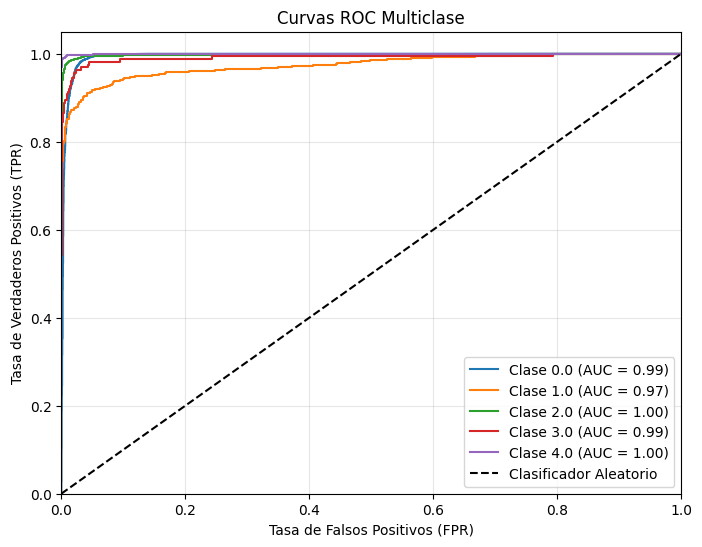

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = xgb_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

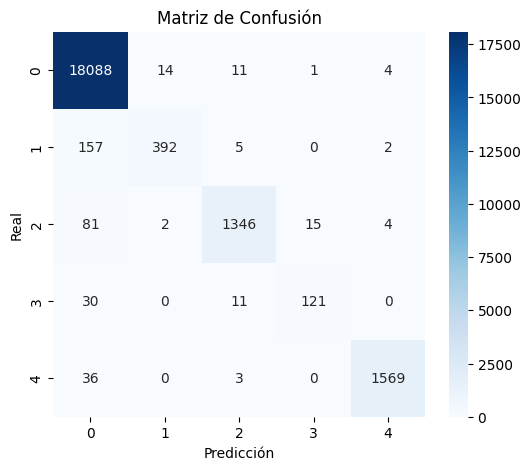

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(xgb_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", xgb_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     18118
         1.0       0.96      0.71      0.81       556
         2.0       0.98      0.93      0.95      1448
         3.0       0.88      0.75      0.81       162
         4.0       0.99      0.98      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.96      0.87      0.91     21892
weighted avg       0.98      0.98      0.98     21892



### LinearSVM

In [ ]:
# Libraies for SVM
from sklearn.svm import LinearSVC

In [ ]:
# Set hyperparameters
linear_svc_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 200]
}

In [ ]:
# Modelo LinearSVC
svc_model = LinearSVC(random_state=random_state, dual=False)

# GridSearchCV para LinearSVC
svc_grid_search = GridSearchCV(
    svc_model,
    param_grid=linear_svc_param_grid,
    scoring=scorer,
    cv=cv,
    verbose=verbose,
    n_jobs=n_jobs,
    refit=refit
)

# Entrenamiento y ajuste del modelo
start_time_svc = time.time()
svc_grid_search.fit(X_train, y_train)
training_time_svc = time.time() - start_time_svc

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:

svc_model_name = "linear_svc"

# Evaluación y guardado del modelo
evaluate_and_save_model(svc_grid_search, svc_model_name, X_test, y_test, training_time_svc)

Modelo y resultados guardados exitosamente en 'models/best_linear_svc_model.pkl' y 'results/linear_svc_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
linear_svc_results = joblib.load("results/linear_svc_results.pkl")
cv_results_df = pd.DataFrame(linear_svc_results['cv_results'])

In [ ]:
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_max_iter', 'param_penalty', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

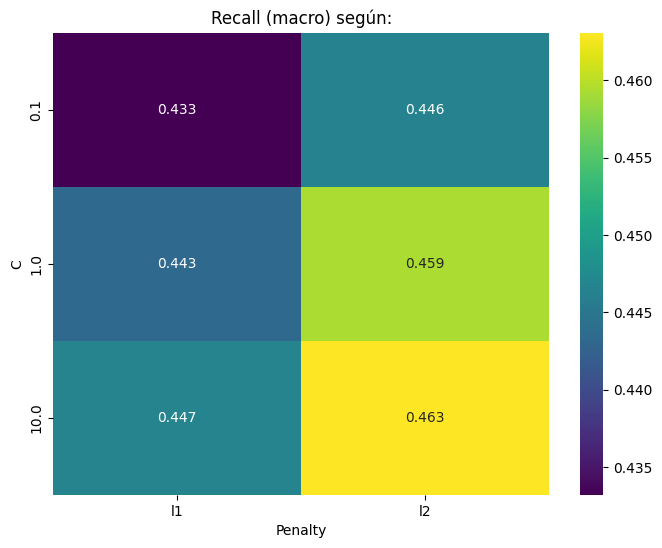

In [ ]:
pivot = cv_results_df.pivot_table(index='param_C',
                                  columns='param_penalty',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según:")
plt.xlabel("Penalty")
plt.ylabel("C")
plt.show()

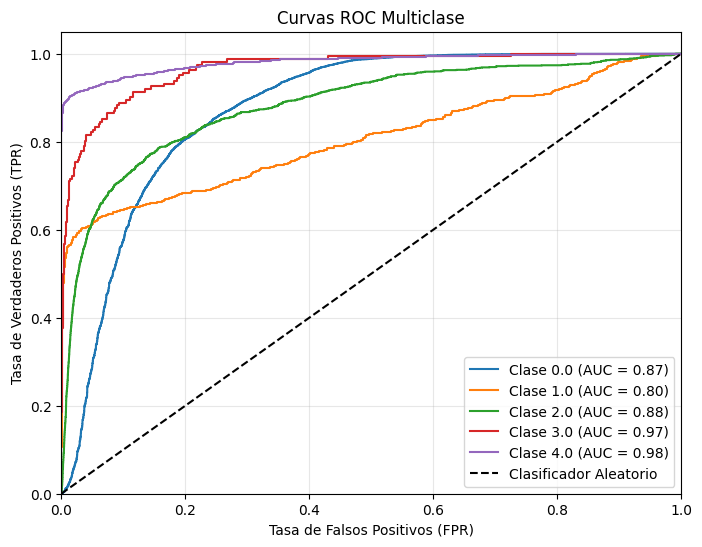

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = linear_svc_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

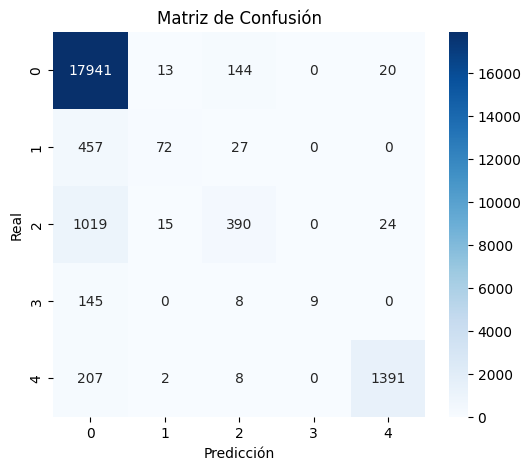

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(linear_svc_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", linear_svc_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     18118
         1.0       0.71      0.13      0.22       556
         2.0       0.68      0.27      0.39      1448
         3.0       1.00      0.06      0.11       162
         4.0       0.97      0.87      0.91      1608

    accuracy                           0.90     21892
   macro avg       0.85      0.46      0.51     21892
weighted avg       0.89      0.90      0.88     21892



### SVM (SVC)

#### Definir los hiperparámetros

In [ ]:

from sklearn.svm import SVC

# Parámetros para SVC
svc_param_grid = {
    'C': [0.1, 1.0, 10.],
    'kernel': ['linear', 'rbf'],
    #'gamma': ['scale', 'auto']
}

In [ ]:
# Modelo SVC
svc_model = SVC(random_state=random_state, probability=True)

# GridSearchCV para SVC
svc_grid_search = GridSearchCV(
    svc_model,
    param_grid=svc_param_grid,
    scoring=scorer,
    cv=cv,
    verbose=verbose,
    n_jobs=n_jobs,
    refit=refit
)

# Entrenamiento y ajuste del modelo
start_time_svc = time.time()
svc_grid_search.fit(X_train, y_train)
training_time_svc = time.time() - start_time_svc

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [ ]:
# Nombre del modelo
svc_model_name = "svc"

# Evaluación y guardado del modelo
evaluate_and_save_model(svc_grid_search, svc_model_name, X_test, y_test, training_time_svc)

Modelo y resultados guardados exitosamente en 'models/best_svc_model.pkl' y 'results/svc_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
svc_results = joblib.load("results/svc_results.pkl")
cv_results_df = pd.DataFrame(svc_results['cv_results'])

In [ ]:
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_kernel', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score'],
      dtype='object')

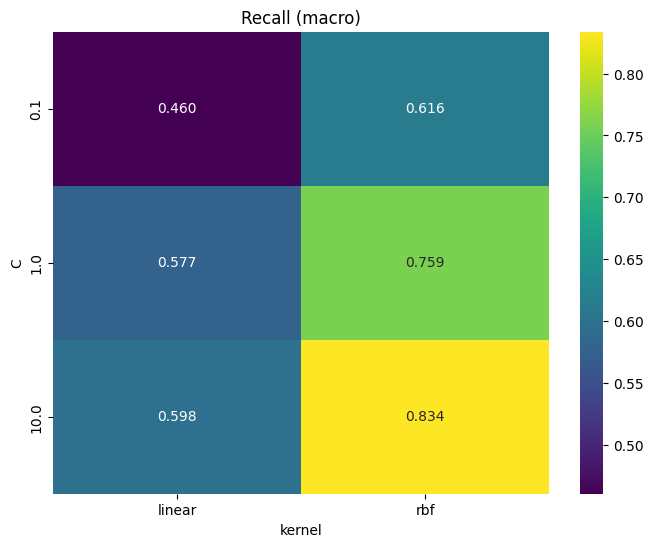

In [ ]:

pivot = cv_results_df.pivot_table(index='param_C',
                                  columns='param_kernel',
                                  values='mean_test_score')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("kernel")
plt.ylabel("C")
plt.show()

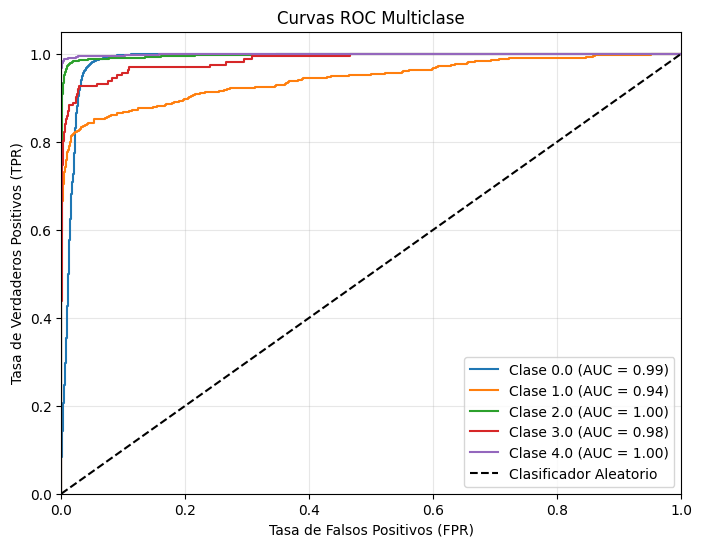

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = svc_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

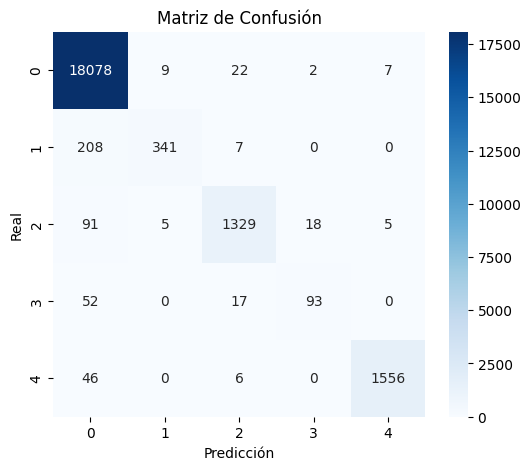

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(svc_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", svc_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     18118
         1.0       0.96      0.61      0.75       556
         2.0       0.96      0.92      0.94      1448
         3.0       0.82      0.57      0.68       162
         4.0       0.99      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.81      0.87     21892
weighted avg       0.98      0.98      0.98     21892



In [ ]:
pd.DataFrame(svc_results["cv_results"]).sort_values(by="rank_test_score", ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,2233.969802,436.758923,67.022623,57.874770,10.0,rbf,"{'C': 10.0, 'kernel': 'rbf'}",0.832433,0.843225,0.835353,0.837872,0.820227,0.833822,0.007667,1
3,2767.927592,397.387533,114.976649,101.671240,1.0,rbf,"{'C': 1.0, 'kernel': 'rbf'}",0.754018,0.764739,0.764034,0.763727,0.750244,0.759352,0.006025,2
1,4396.757558,528.677218,172.372242,150.589776,0.1,rbf,"{'C': 0.1, 'kernel': 'rbf'}",0.605936,0.618103,0.614637,0.622205,0.619712,0.616119,0.005653,3
4,8877.127614,610.550724,35.011635,7.983089,10.0,linear,"{'C': 10.0, 'kernel': 'linear'}",0.572580,0.599484,0.600848,0.615721,0.600032,0.597733,0.013959,4
2,5552.381414,108.362752,79.070506,4.659726,1.0,linear,"{'C': 1.0, 'kernel': 'linear'}",0.555127,0.574629,0.582190,0.589673,0.581227,0.576569,0.011735,5
0,4864.826110,34.544831,96.425620,4.032074,0.1,linear,"{'C': 0.1, 'kernel': 'linear'}",0.457985,0.459231,0.463721,0.461604,0.459738,0.460456,0.002005,6


### MLP (sklearn)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
# Set hyperparameters
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['logistic', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200, 500]
}

In [ ]:
# Modelo MLPClassifier
mlp_model = MLPClassifier(random_state=random_state)

# GridSearchCV para MLPClassifier
mlp_grid_search = GridSearchCV(
    mlp_model,
    param_grid=mlp_param_grid,
    scoring=scorer,
    cv=cv,
    verbose=verbose,
    n_jobs=n_jobs,
    refit=refit
)

# Entrenamiento y ajuste del modelo
start_time_mlp = time.time()
mlp_grid_search.fit(X_train, y_train)
training_time_mlp = time.time() - start_time_mlp

Fitting 5 folds for each of 96 candidates, totalling 480 fits


c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Nombre del modelo
mlp_model_name = "mlp"

# Evaluación y guardado del modelo
evaluate_and_save_model(mlp_grid_search, mlp_model_name, X_test, y_test, training_time_mlp)

Modelo y resultados guardados exitosamente en 'models/best_mlp_model.pkl' y 'results/mlp_results.pkl'.


#### Análisis de resultados generales y test

In [ ]:
mlp_results = joblib.load("results/mlp_results.pkl")
cv_results_df = pd.DataFrame(mlp_results['cv_results'])

In [ ]:
cv_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_activation', 'param_alpha', 'param_hidden_layer_sizes',
       'param_learning_rate', 'param_max_iter', 'param_solver', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

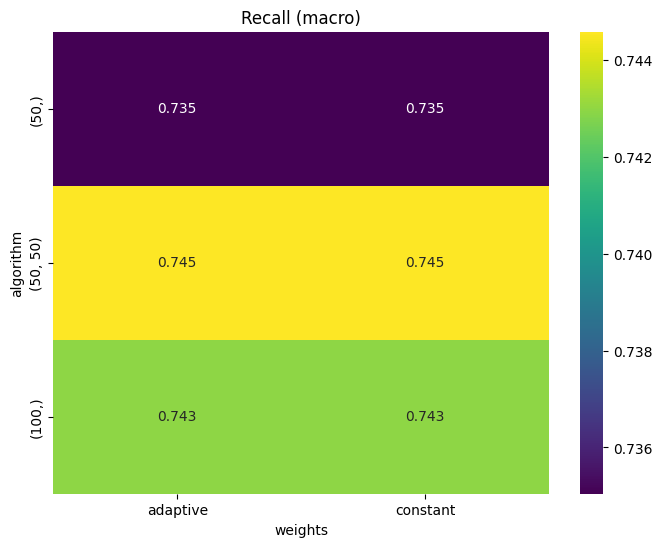

In [ ]:
pivot = cv_results_df.pivot_table(index='param_hidden_layer_sizes',
                                  columns='param_learning_rate',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("weights")
plt.ylabel("algorithm")
plt.show()

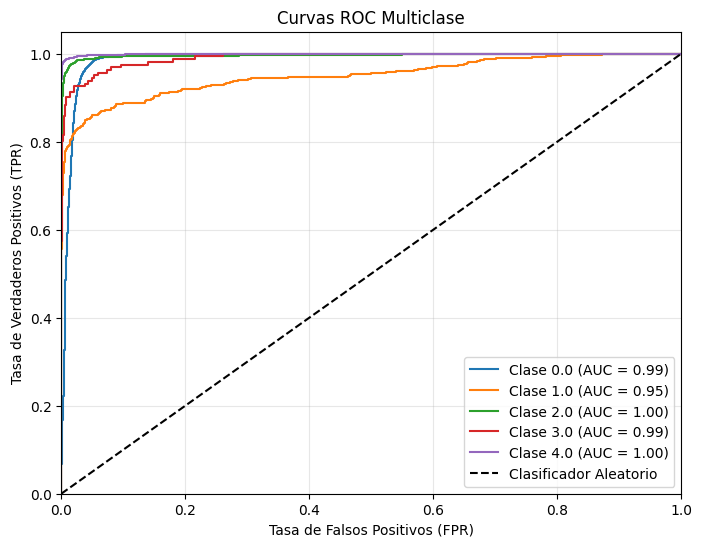

In [ ]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = mlp_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

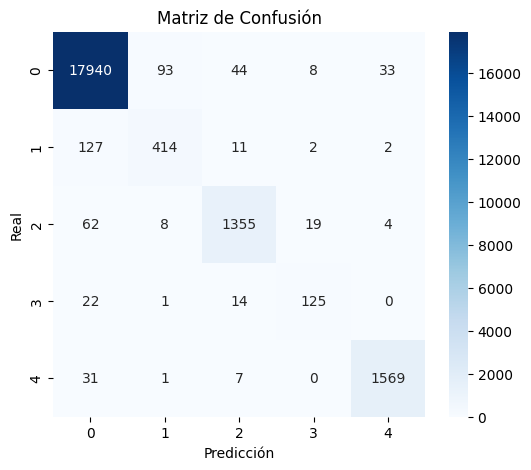

In [ ]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(mlp_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", mlp_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.80      0.74      0.77       556
         2.0       0.95      0.94      0.94      1448
         3.0       0.81      0.77      0.79       162
         4.0       0.98      0.98      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.88      0.89     21892
weighted avg       0.98      0.98      0.98     21892



### Configuración para los modelos con GPU

In [3]:
# Liberías para todos los modelos con GPU
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, metrics, models, optimizers, losses
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Dense, Input

device_name = tf.config.list_physical_devices('GPU')
print(f"Usando {device_name}")

Usando [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def evaluate_and_save_keras_model(model, model_name, X_test, y_test, training_time):
    """
    Evalúa el modelo Keras y guarda los resultados de la evaluación junto con el modelo.

    Parámetros:
    - model: Modelo Keras entrenado.
    - model_name (str): Nombre del modelo para guardar resultados.
    - X_test (array-like): Datos de prueba.
    - y_test (array-like): Etiquetas de prueba en formato one-hot.
    - training_time (float): Tiempo de entrenamiento (o búsqueda) en segundos.

    Se guardan:
    - Resultados de evaluación en 'results/{model_name}_results.pkl'
    - Modelo guardado en 'models/best_{model_name}_model.h5'
    
    Métricas calculadas: precisión, recall, accuracy, F1, matriz de confusión,
    ROC AUC (multiclase) y reporte de clasificación.
    """

    # Obtener predicciones y convertir a etiquetas
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Calcular ROC AUC si es posible (multiclase 'ovr')
    try:
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    except Exception:
        auc = float('nan')
    
    # Calcular otras métricas
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    
    # Guardar resultados en un diccionario
    results = {
        'precision_test': precision,
        'recall_test': recall,
        'accuracy_test': accuracy,
        'f1_score_test': f1,
        'confusion_matrix': cm,
        'y_pred_prob': y_pred_proba,
        'auc_test': auc,
        'classification_report': report,
        'cpu_time': training_time
    }
    
    # Guardar los resultados y el modelo
    joblib.dump(results, f"results/{model_name}_results.pkl")
    model.save(f"models/best_{model_name}_model.h5")
    print(f"Modelo y resultados guardados en 'models/best_{model_name}_model.h5' y 'results/{model_name}_results.pkl'.")


### LSTM

#### Inicialmente definimos las entradas en un formato válido para la LSTM

In [14]:
# Ajuste de los datos para el modelo LSTM
X = df_train.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y = tf.keras.utils.to_categorical(df_train.iloc[:, -1].values.astype(int), num_classes=5)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_test = df_test.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y_test = tf.keras.utils.to_categorical(df_test.iloc[:, -1].values.astype(int), num_classes=5)

#### Construimos el espacio de búsqueda con Keras tunner

In [ ]:
# Función para construir el modelo LSTM con Keras Tuner
def build_model_lstm(hp):
    model = Sequential()
    # Primera capa LSTM
    model.add(layers.LSTM(
        units=hp.Int('lstm_units', 32, 128, step=32),
        return_sequences=True,
        input_shape=(187, 1)
    ))
    model.add(layers.Dropout(hp.Float('dropout1',0.0, 0.3, step=0.1)))
    
    # Segunda capa LSTM
    model.add(layers.LSTM(
        units=hp.Int('lstm_units2', 32, 128, step=32)
    ))
    model.add(layers.Dropout(hp.Float('dropout2',0.0, 0.3, step=0.1)))
    
    # Capa densa
    model.add(layers.Dense(
        units=hp.Int('dense_units', 32, 128, step=32),
        activation='relu'
    ))
    model.add(layers.Dense(5, activation='softmax'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy', # Función de pérdida para clasificación multiclase
        metrics=[metrics.Recall(name='recall'), 'accuracy'] # Se calcula el recall
    )
    return model

In [22]:
tuner_lstm = kt.Hyperband(
    build_model_lstm,
    objective=kt.Objective("val_recall", direction="max"),
    max_epochs=100,
    seed=42,
    directory='models', 
    project_name='lstm',
    overwrite=True
)

tuner_lstm.search_space_summary()

Search space summary
Default search space size: 6
lstm_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
lstm_units2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
lr (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [25]:
# Early stopping para evitar sobreajuste
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#### Exploración de hiperparámetros

In [ ]:

start_time_tuner = time.time()
tuner_lstm.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
search_time_tuner = time.time() - start_time_tuner

Trial 248 Complete [00h 05m 42s]
val_recall: 0.9443778395652771

Best val_recall So Far: 0.9840671420097351
Total elapsed time: 18h 19m 04s

Search: Running Trial #249

Value             |Best Value So Far |Hyperparameter
128               |128               |lstm_units
0.1               |0.1               |dropout1
32                |128               |lstm_units2
0                 |0.1               |dropout2
96                |32                |dense_units
0.001             |0.001             |lr
100               |100               |tuner/epochs
0                 |34                |tuner/initial_epoch
0                 |3                 |tuner/bracket
0                 |3                 |tuner/round

Epoch 1/100
1095/1095 [==============================] - 51s 44ms/step - loss: 0.6694 - recall: 0.8200 - accuracy: 0.8273 - val_loss: 0.6581 - val_recall: 0.8277 - val_accuracy: 0.8277
Epoch 2/100
1095/1095 [==============================] - 49s 45ms/step - loss: 0.6593 - recall: 0

In [26]:
# Definimos el mejor modelo:
final_lstm_model = models.Sequential()
final_lstm_model.add(layers.LSTM(128, return_sequences=True, input_shape=(187, 1)))
final_lstm_model.add(layers.Dropout(0.1))
final_lstm_model.add(layers.LSTM(128))
final_lstm_model.add(layers.Dropout(0.1))
final_lstm_model.add(layers.Dense(32, activation='relu'))
final_lstm_model.add(layers.Dense(5, activation='sigmoid'))

# Compilar modelo
optimizer = optimizers.Adam(learning_rate=0.001)
final_lstm_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'Recall'])
final_lstm_model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_14 (LSTM)              (None, 187, 128)          66560     
                                                                 
 dropout_14 (Dropout)        (None, 187, 128)          0         
                                                                 
 lstm_15 (LSTM)              (None, 128)               131584    
                                                                 
 dropout_15 (Dropout)        (None, 128)               0         
                                                                 
 dense_14 (Dense)            (None, 32)                4128      
                                                                 
 dense_15 (Dense)            (None, 5)                 165       
                                                                 
Total params: 202,437
Trainable params: 202,437
Non-tr

In [27]:
history_lstm = final_lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/100
1095/1095 [==============================] - 60s 52ms/step - loss: 0.2312 - accuracy: 0.8277 - recall: 0.8274 - val_loss: 0.2273 - val_accuracy: 0.8277 - val_recall: 0.8277
Epoch 2/100
1095/1095 [==============================] - 55s 51ms/step - loss: 0.2268 - accuracy: 0.8273 - recall: 0.8274 - val_loss: 0.2256 - val_accuracy: 0.8277 - val_recall: 0.8277
Epoch 3/100
1095/1095 [==============================] - 56s 51ms/step - loss: 0.2265 - accuracy: 0.8277 - recall: 0.8277 - val_loss: 0.2256 - val_accuracy: 0.8277 - val_recall: 0.8277
Epoch 4/100
1095/1095 [==============================] - 56s 51ms/step - loss: 0.2176 - accuracy: 0.8279 - recall: 0.8241 - val_loss: 0.1731 - val_accuracy: 0.8216 - val_recall: 0.7837
Epoch 5/100
1095/1095 [==============================] - 56s 51ms/step - loss: 0.1495 - accuracy: 0.8769 - recall: 0.8567 - val_loss: 0.1363 - val_accuracy: 0.8893 - val_recall: 0.8870
Epoch 6/100
1095/1095 [==============================] - 56s 51ms/step - lo

In [ ]:
# Se evalúa el modelo con los datos de test y se guardan los resultados
evaluate_and_save_keras_model(final_lstm_model, "lstm", X_test, y_test, search_time_tuner)

685/685 [==============================] - 13s 18ms/step
Modelo y resultados guardados en 'models/best_lstm_model.h5' y 'results/lstm_results.pkl'.


#### Análisis de resultados generales y de test

In [48]:
lstm_results = joblib.load("results/lstm_results.pkl")

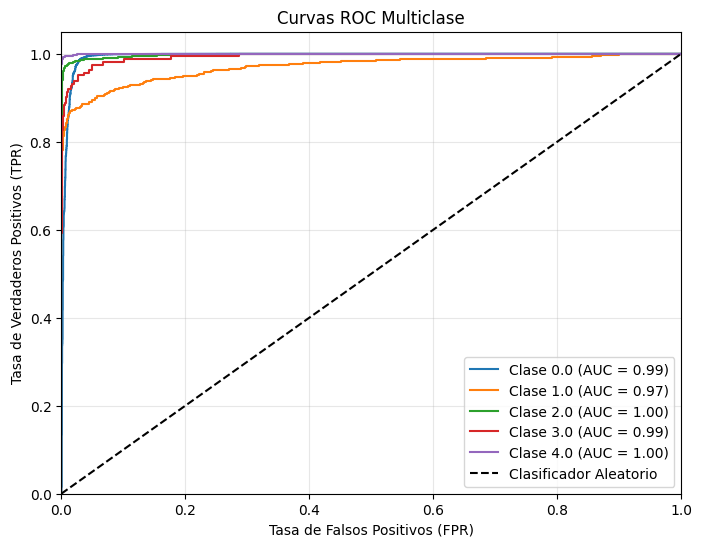

In [49]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = lstm_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

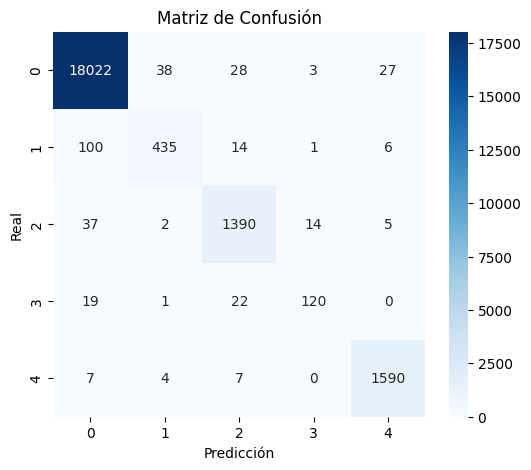

In [50]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(lstm_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [5]:
print(lstm_results["classification_report"])

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.91      0.78      0.84       556
           2       0.95      0.96      0.96      1448
           3       0.87      0.74      0.80       162
           4       0.98      0.99      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.89      0.91     21892
weighted avg       0.98      0.98      0.98     21892



### CNN

In [24]:
# Inicialmente ajustamos los datos al formato requerido

X = df_train.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y = tf.keras.utils.to_categorical(df_train.iloc[:, -1].values.astype(int), num_classes=5)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_test = df_test.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y_test = tf.keras.utils.to_categorical(df_test.iloc[:, -1].values.astype(int), num_classes=5)

In [2]:
# Definimos el modelo CNN con Keras Tuner y sus hiperparámetros
def build_model_cnn(hp):
    model = Sequential()
    
    model.add(layers.Conv1D(
        filters=hp.Int('filters', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size', [3, 5, 7]),
        activation='relu',
        input_shape=(187, 1)
    ))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))
    
    model.add(layers.Conv1D(
        filters=hp.Int('filters2', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size2', [3, 5]),
        activation='relu'
    ))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))
    
    model.add(layers.Flatten())
    model.add(Dense(
        units=hp.Int('dense_units', 32, 128, step=32),
        activation='relu'
    ))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=[metrics.Recall(name='recall'), 'accuracy']
    )
    return model

In [ ]:
# Se define le tunner utilizando el modelo y se crear un early stopping para evitar el sobreajuste
tuner_cnn = kt.Hyperband(
    build_model_cnn,
    objective=kt.Objective('val_recall', direction='max'),
    max_epochs=100,
    seed=42,
    directory='models',
    project_name='cnn'
)

tuner_cnn.search_space_summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

Search space summary
Default search space size: 8
filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
kernel_size (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5, 7], 'ordered': True}
dropout1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
filters2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
kernel_size2 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
dropout2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
lr (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [14]:
start_time_tuner = time.time()
tuner_cnn.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
search_time_tuner = time.time() - start_time_tuner

Trial 254 Complete [00h 07m 19s]
val_recall: 0.973388135433197

Best val_recall So Far: 0.9876648783683777
Total elapsed time: 03h 39m 47s


In [ ]:
# Con esto, lo mejores hyperparámetros
best_hps_cnn = tuner_cnn.get_best_hyperparameters(1)[0]
print("\n Mejores hiperparámetros encontrados:")
print(f"Filters: {best_hps_cnn.get('filters')}")
print(f"Kernel size: {best_hps_cnn.get('kernel_size')}")
print(f"Dense units: {best_hps_cnn.get('dense_units')}")
print(f"Dropout: {best_hps_cnn.get('dropout1')}, {best_hps_cnn.get('dropout2')}")
print(f"Learning rate: {best_hps_cnn.get('lr')}")


 Mejores hiperparámetros encontrados:
Filters: 96
Kernel size: 5
Dense units: 128
Dropout: 0.30000000000000004, 0.30000000000000004
Learning rate: 0.001


In [ ]:
# Se define el modelo final con los mejores hiperparámetros y se entrena nuevamente
final_cnn_model = tuner_cnn.hypermodel.build(best_hps_cnn)
final_cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 183, 96)           576       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 91, 96)           0         
 1D)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 91, 96)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 87, 64)            30784     
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 43, 64)           0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 43, 64)           

In [22]:
history_cnn = final_cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
1095/1095 [==============================] - 9s 8ms/step - loss: 0.2415 - recall: 0.9243 - accuracy: 0.9325 - val_loss: 0.1448 - val_recall: 0.9553 - val_accuracy: 0.9578
Epoch 2/50
1095/1095 [==============================] - 8s 7ms/step - loss: 0.1349 - recall: 0.9597 - accuracy: 0.9626 - val_loss: 0.1125 - val_recall: 0.9671 - val_accuracy: 0.9690
Epoch 3/50
1095/1095 [==============================] - 8s 7ms/step - loss: 0.1086 - recall: 0.9670 - accuracy: 0.9689 - val_loss: 0.0972 - val_recall: 0.9709 - val_accuracy: 0.9720
Epoch 4/50
1095/1095 [==============================] - 7s 7ms/step - loss: 0.0912 - recall: 0.9719 - accuracy: 0.9734 - val_loss: 0.0817 - val_recall: 0.9749 - val_accuracy: 0.9762
Epoch 5/50
1095/1095 [==============================] - 7s 7ms/step - loss: 0.0803 - recall: 0.9753 - accuracy: 0.9766 - val_loss: 0.0752 - val_recall: 0.9779 - val_accuracy: 0.9790
Epoch 6/50
1095/1095 [==============================] - 7s 7ms/step - loss: 0.0727 - recal

In [ ]:
# Se evalúa el modelo con los datos de test y se guardan los resultados
evaluate_and_save_keras_model(final_cnn_model, "cnn", X_test, y_test, search_time_tuner)

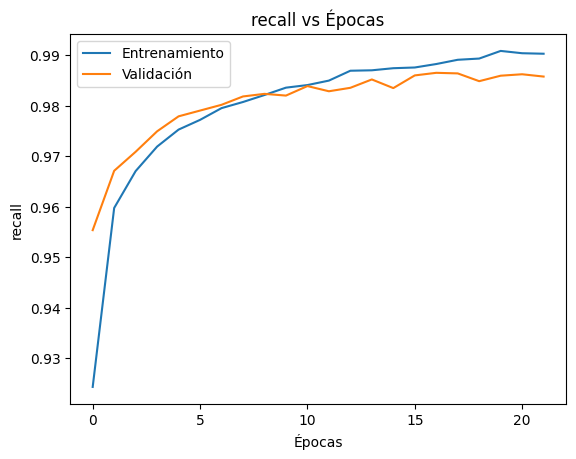

In [26]:
plt.plot(history_cnn.history['recall'], label='Entrenamiento')
plt.plot(history_cnn.history['val_recall'], label='Validación')
plt.title('recall vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('recall')
plt.legend()

#### Análisis de los resultados para CNN

In [ ]:
cnn_results = joblib.load("results/cnn_results.pkl") # Se cargan los rulustados obtenidos

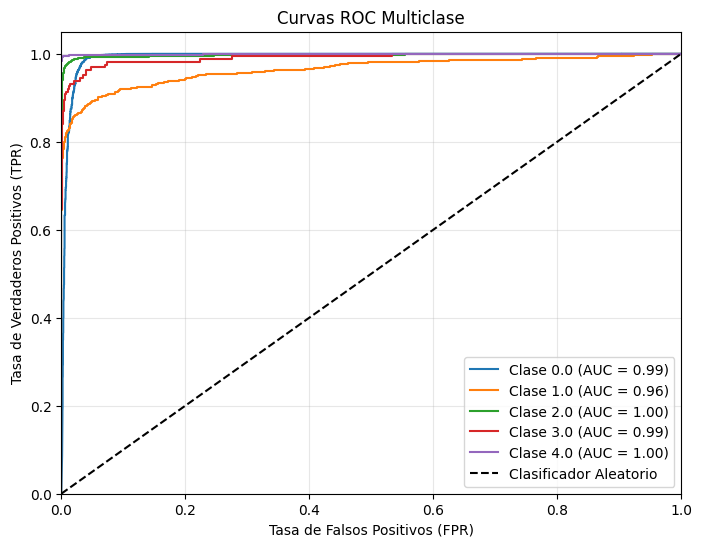

In [47]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = cnn_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

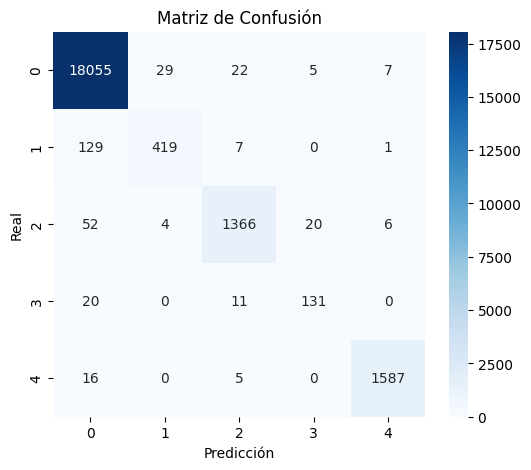

In [29]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cnn_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [28]:
print(cnn_results["classification_report"])

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.93      0.75      0.83       556
           2       0.97      0.94      0.96      1448
           3       0.84      0.81      0.82       162
           4       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.90      0.92     21892
weighted avg       0.98      0.98      0.98     21892



### Autoencoder

In [20]:
# Ajuste de los datos para el autoencoder
X = df_train.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y = tf.keras.utils.to_categorical(df_train.iloc[:, -1].values.astype(int), num_classes=5)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_test = df_test.iloc[:, :-1].values.reshape((-1, 187, 1)).astype(np.float32)
y_test = tf.keras.utils.to_categorical(df_test.iloc[:, -1].values.astype(int), num_classes=5)

In [19]:
def build_autoencoder_model(hp):
    lstm_units = hp.Int('lstm_units', 64, 128, step=32)
    dense_units = hp.Int('dense_units', 64, 128, step=32)
    dropout_rate = hp.Float('dropout_rate', 0.0, 0.2, step=0.1)
    alpha = hp.Choice('alpha', [0.25, 0.5])
    beta  = hp.Choice('beta',  [0.25, 0.5])

    inputs =  Input(shape=(187, 1))

    # Encoder
    x = layers.LSTM(lstm_units, return_sequences=False)(inputs)
    x = layers.Dropout(dropout_rate)(x)
    bottleneck = layers.Dense(dense_units, activation='relu')(x)

    # Decoder
    x_dec = layers.RepeatVector(187)(bottleneck)
    x_dec = layers.LSTM(lstm_units, return_sequences=True)(x_dec)
    outputs_recon = layers.TimeDistributed(layers.Dense(1), name='reconstruction')(x_dec)

    # Clasificador
    outputs_class = layers.Dense(5, activation='softmax', name='classification')(bottleneck)

    model = Model(inputs=inputs, outputs=[outputs_recon, outputs_class])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])
        ),
        loss={
            'reconstruction': losses.MeanSquaredError(),
            'classification': losses.CategoricalCrossentropy()
        },
        loss_weights={'reconstruction': alpha, 'classification': beta},
        metrics={'classification': [metrics.Recall(name='recall'), 'accuracy']}
    )

    return model


In [21]:
tuner_autoencoder = kt.Hyperband(
    build_autoencoder_model,
    objective=kt.Objective("val_classification_recall", direction="max"),
    max_epochs=30,
    seed=42,
    executions_per_trial=1,
    directory='models', 
    project_name='autoencoder',
    overwrite=True
)
tuner_autoencoder.search_space_summary()

Search space summary
Default search space size: 6
lstm_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.2, 'step': 0.1, 'sampling': 'linear'}
alpha (Choice)
{'default': 0.25, 'conditions': [], 'values': [0.25, 0.5], 'ordered': True}
beta (Choice)
{'default': 0.25, 'conditions': [], 'values': [0.25, 0.5], 'ordered': True}
lr (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_classification_recall',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [23]:
start_time_tuner = time.time()

tuner_autoencoder.search(
    X_train,
    {'reconstruction': X_train, 'classification': y_train},
    epochs=10,
    validation_data=(X_val, {'reconstruction': X_val, 'classification': y_val}),
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

search_time_tuner = time.time() - start_time_tuner

Trial 90 Complete [00h 22m 21s]
val_classification_recall: 0.8899548649787903

Best val_classification_recall So Far: 0.9801838994026184
Total elapsed time: 07h 38m 59s


In [37]:
# Con esto, lo mejores hyperparámetros
best_hps_ae = tuner_autoencoder.get_best_hyperparameters(1)[0]

# Se define el modelo final con los mejores hiperparámetros y se entrena nuevamente
final_ae_model = tuner_autoencoder.hypermodel.build(best_hps_ae)
final_ae_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 187, 1)]     0           []                               
                                                                                                  
 lstm_4 (LSTM)                  (None, 128)          66560       ['input_3[0][0]']                
                                                                                                  
 dropout_2 (Dropout)            (None, 128)          0           ['lstm_4[0][0]']                 
                                                                                                  
 dense_4 (Dense)                (None, 128)          16512       ['dropout_2[0][0]']              
                                                                                            

In [38]:
history_autoencoder = final_ae_model.fit(
    X_train, {'reconstruction': X_train, 'classification': y_train},
    epochs=100,
    batch_size=64,
    validation_data=(X_val, {'reconstruction': X_val, 'classification': y_val}),
    callbacks=[early_stop]
)

Epoch 1/100
1095/1095 [==============================] - 61s 53ms/step - loss: 0.1864 - reconstruction_loss: 0.0388 - classification_loss: 0.6682 - classification_recall: 0.8191 - classification_accuracy: 0.8273 - val_loss: 0.1762 - val_reconstruction_loss: 0.0303 - val_classification_loss: 0.6441 - val_classification_recall: 0.8277 - val_classification_accuracy: 0.8277
Epoch 2/100
1095/1095 [==============================] - 56s 51ms/step - loss: 0.1602 - reconstruction_loss: 0.0301 - classification_loss: 0.5807 - classification_recall: 0.8076 - classification_accuracy: 0.8316 - val_loss: 0.1829 - val_reconstruction_loss: 0.0345 - val_classification_loss: 0.6625 - val_classification_recall: 0.8278 - val_classification_accuracy: 0.8278
Epoch 3/100
1095/1095 [==============================] - 55s 51ms/step - loss: 0.1572 - reconstruction_loss: 0.0300 - classification_loss: 0.5689 - classification_recall: 0.8332 - classification_accuracy: 0.8437 - val_loss: 0.1266 - val_reconstruction_lo

In [23]:
# Obtener predicciones y convertir a etiquetas
y_pred_proba = final_ae_model.predict(X_test)
y_pred = np.argmax(y_pred_proba[1], axis=1)
y_true = np.argmax(y_test, axis=1)

685/685 [==============================] - 13s 19ms/step


In [35]:
# Calcular ROC AUC si es posible (multiclase 'ovr')
try:
    auc = roc_auc_score(y_test, y_pred_proba[1], multi_class='ovr')
except Exception:
    auc = float('nan')

In [36]:
# Calcular otras métricas
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

results = {
    'precision_test': precision,
    'recall_test': recall,
    'accuracy_test': accuracy,
    'f1_score_test': f1,
    'confusion_matrix': cm,
    'y_pred_prob': y_pred_proba,
    'auc_test': auc,
    'classification_report': report,
    'cpu_time': search_time_tuner
}
    

In [37]:
model_name = 'autoencoder'

# Guardar los resultados y el modelo
joblib.dump(results, f"results/{model_name}_results.pkl")
final_ae_model.save(f"models/best_{model_name}_model.h5")
print(f"Modelo y resultados guardados en 'models/best_{model_name}_model.h5' y 'results/{model_name}_results.pkl'.")

Modelo y resultados guardados en 'models/best_autoencoder_model.h5' y 'results/autoencoder_results.pkl'.


#### Análisis de resultados

In [38]:
autoencoder_results = joblib.load("results/autoencoder_results.pkl")

In [39]:
print(autoencoder_results["classification_report"])

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18118
           1       0.86      0.69      0.77       556
           2       0.96      0.91      0.94      1448
           3       0.71      0.71      0.71       162
           4       0.98      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.86      0.88     21892
weighted avg       0.98      0.98      0.98     21892



## 3. Comparación de resultados de todos los modelos

Finalmente, se presentan los resultados finales los las métricas de los modelos evaluados.

In [72]:
def cargar_resultados(directorio):
    archivos = [f for f in os.listdir(directorio) if f.endswith(".pkl")]
    resultados_totales = []
    for archivo in archivos:
        try:
            data = joblib.load(os.path.join(directorio, archivo))
            if isinstance(data, dict):
                nombre_archivo_sin_extension = os.path.splitext(archivo)[0]
                data["model_name"] = nombre_archivo_sin_extension
                resultados_totales.append(data)
        except Exception as e:
            print(f"Error al cargar el archivo {archivo}: {e}")
    return resultados_totales

resultados_totales = cargar_resultados('results/')

In [73]:
dict_to_df = []

for item in resultados_totales:
    dict_to_df.append({
        "model_name": item["model_name"],
        "precission" : item["precision_test"],
        "recall_macro": item["recall_test"],
        "accuracy": item["accuracy_test"],
        "f1_score": item["f1_score_test"],
        "auc": item["auc_test"],
        "total_cpu_time_min": item["cpu_time"]/60,
    })

In [74]:
results_summary = pd.DataFrame(dict_to_df).sort_values(by="recall_macro", ascending=False).reset_index(drop=True)
results_summary

,model_name,precission,recall_macro,accuracy,f1_score,auc,total_cpu_time_min
0,cnn_results,0.942844,0.897814,0.984743,0.918445,0.988604,219.797408
1,lstm_results,0.938983,0.893313,0.984698,0.914197,0.991004,18.800000
2,mlp_results,0.904358,0.883581,0.977663,0.893657,0.984824,307.610415
3,xgb_results,0.959866,0.871120,0.982825,0.910275,0.991387,52.817633
4,knn_results,0.899565,0.868556,0.976201,0.883464,0.925557,32.473809
5,autoencoder_results,0.900989,0.855815,0.977298,0.876356,0.987603,458.988292
6,tree_results,0.831897,0.823717,0.961264,0.827697,0.903896,2.984338
7,svc_results,0.943355,0.814131,0.977389,0.866491,0.981456,287.041197
8,rf_results,0.962265,0.812568,0.974831,0.873681,0.992569,56.346595
9,reglog_results,0.787554,0.598089,0.914809,0.664022,0.917592,40.129006


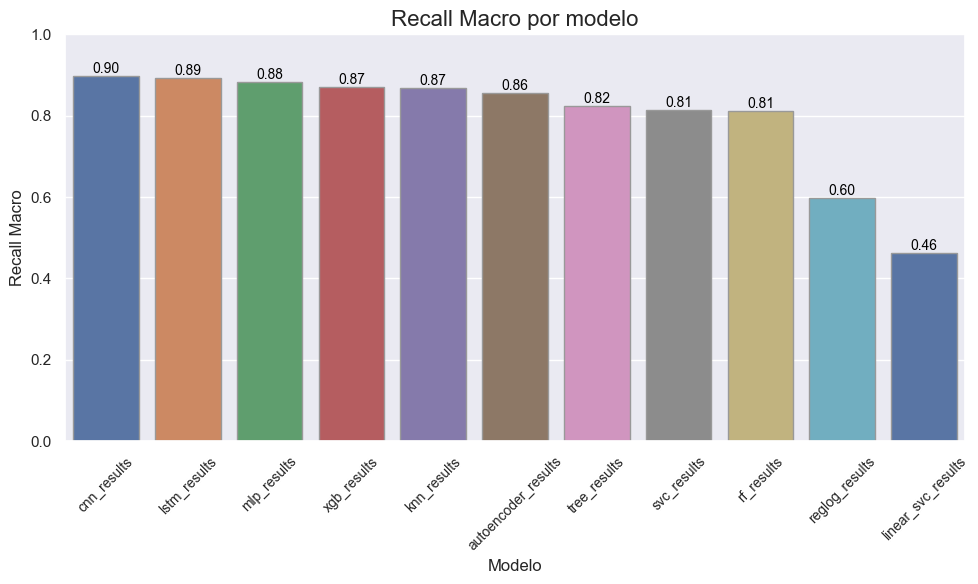

In [75]:
# Estilo de seaborn
sns.set_theme()

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=results_summary, 
    x="model_name", 
    y="recall_macro",
    hue='model_name',
    palette="deep", 
    edgecolor=".6"
)

# Añadir valores encima de las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=10, color='black')


plt.title("Recall Macro por modelo", fontsize=16)
plt.xlabel("Modelo", fontsize=12)
plt.ylabel("Recall Macro", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()